In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
bank_fd=pd.read_csv(r"C:\Users\achin\Downloads\DataSets(Nareshit)\bank.csv",sep=';')
cat=bank_fd.select_dtypes(include='object').columns
num=bank_fd.select_dtypes(exclude='object').columns

In [4]:
cat

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome', 'y'],
      dtype='object')

In [5]:
num

Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')

In [6]:
labels=bank_fd['job'].unique()
labels

array(['unemployed', 'services', 'management', 'blue-collar',
       'self-employed', 'technician', 'entrepreneur', 'admin.', 'student',
       'housemaid', 'retired', 'unknown'], dtype=object)

In [7]:
job=bank_fd['job']=='unemployed'
bank_fd[job]

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
79,40,unemployed,married,secondary,no,219,yes,no,cellular,17,nov,204,2,196,1,failure,no
99,31,unemployed,single,primary,no,406,no,no,cellular,4,feb,736,1,-1,0,unknown,yes
108,56,unemployed,married,primary,no,3391,no,no,cellular,21,apr,243,1,-1,0,unknown,yes
126,24,unemployed,single,secondary,no,119,no,no,unknown,15,sep,51,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4417,33,unemployed,married,tertiary,no,302,yes,yes,cellular,16,apr,670,1,-1,0,unknown,no
4448,44,unemployed,married,secondary,no,304,yes,no,unknown,12,may,129,2,-1,0,unknown,no
4467,43,unemployed,divorced,secondary,no,1577,yes,no,cellular,19,nov,87,1,-1,0,unknown,no
4488,31,unemployed,single,secondary,no,315,no,no,cellular,30,jan,130,1,2,1,other,no


In [8]:
uni=bank_fd['job'].unique().tolist()
l=[]
for i in uni:
    a=bank_fd['job']==i
    l.append(len(bank_fd[a]))
l


[128, 417, 969, 946, 183, 768, 168, 478, 84, 112, 230, 38]

In [9]:

job=uni
job_fd=pd.DataFrame(zip(labels,l),columns=['Jobs','Frequency'])
job_fd.to_csv('job_fd.csv',index=False)

In [10]:

count=[]
for i in cat[1:]:
    labels=bank_fd[i].unique()
    for label in labels:
        a=bank_fd[i]==label
        count.append(len(bank_fd[a]))
    ff=pd.DataFrame(zip(labels,count),columns=[i,'Count'])
    ff.to_csv(f'{i}_fd.csv',index=False)


In [11]:
jobs=bank_fd['job'].value_counts()
jobs

job
management       969
blue-collar      946
technician       768
admin.           478
services         417
retired          230
self-employed    183
entrepreneur     168
unemployed       128
housemaid        112
student           84
unknown           38
Name: count, dtype: int64

In [12]:
bank_fd.groupby('job').size()

job
admin.           478
blue-collar      946
entrepreneur     168
housemaid        112
management       969
retired          230
self-employed    183
services         417
student           84
technician       768
unemployed       128
unknown           38
dtype: int64

In [13]:
import os
folder_name='bank_freq_table'
try:
    os.makedirs(folder_name)
except Exception as e:
    cwd=os.getcwd()
    nwd=os.path.join(cwd,folder_name)

for i in cat[1:]:
    vc=bank_fd[i].value_counts()
    keys=vc.keys()
    values=vc.values
    vc_df=pd.DataFrame(zip(labels,count),columns=['Category','Frequency'])

    file_name=f'{i}_fd.csv'
    path=os.path.join(nwd,file_name)
    
    vc_df.to_csv(path,index=False)

In [14]:
bank_fd[i].value_counts()

y
no     4000
yes     521
Name: count, dtype: int64

# Bar charts

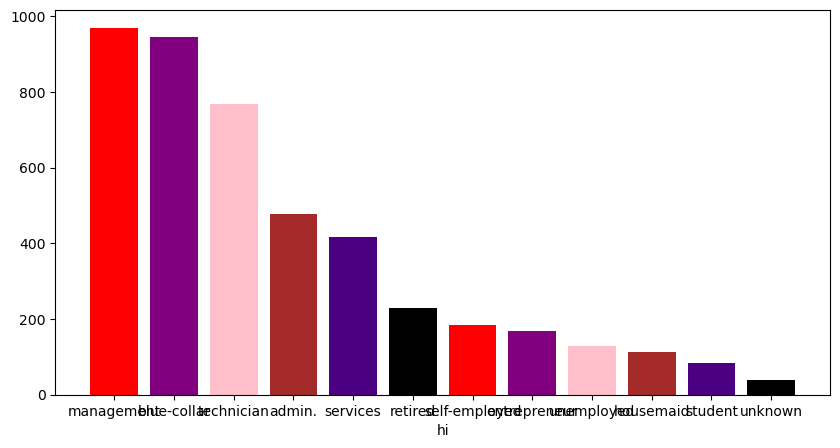

In [16]:
colors=['Red','Purple','Pink','Brown','Indigo','Black']
class_names=bank_fd['job'].value_counts().keys()
class_values=bank_fd['job'].value_counts().values
plt.figure(figsize=(10,5))
plt.bar(class_names,
        class_values,
        color=colors)
plt.xlabel('hi')
plt.show()

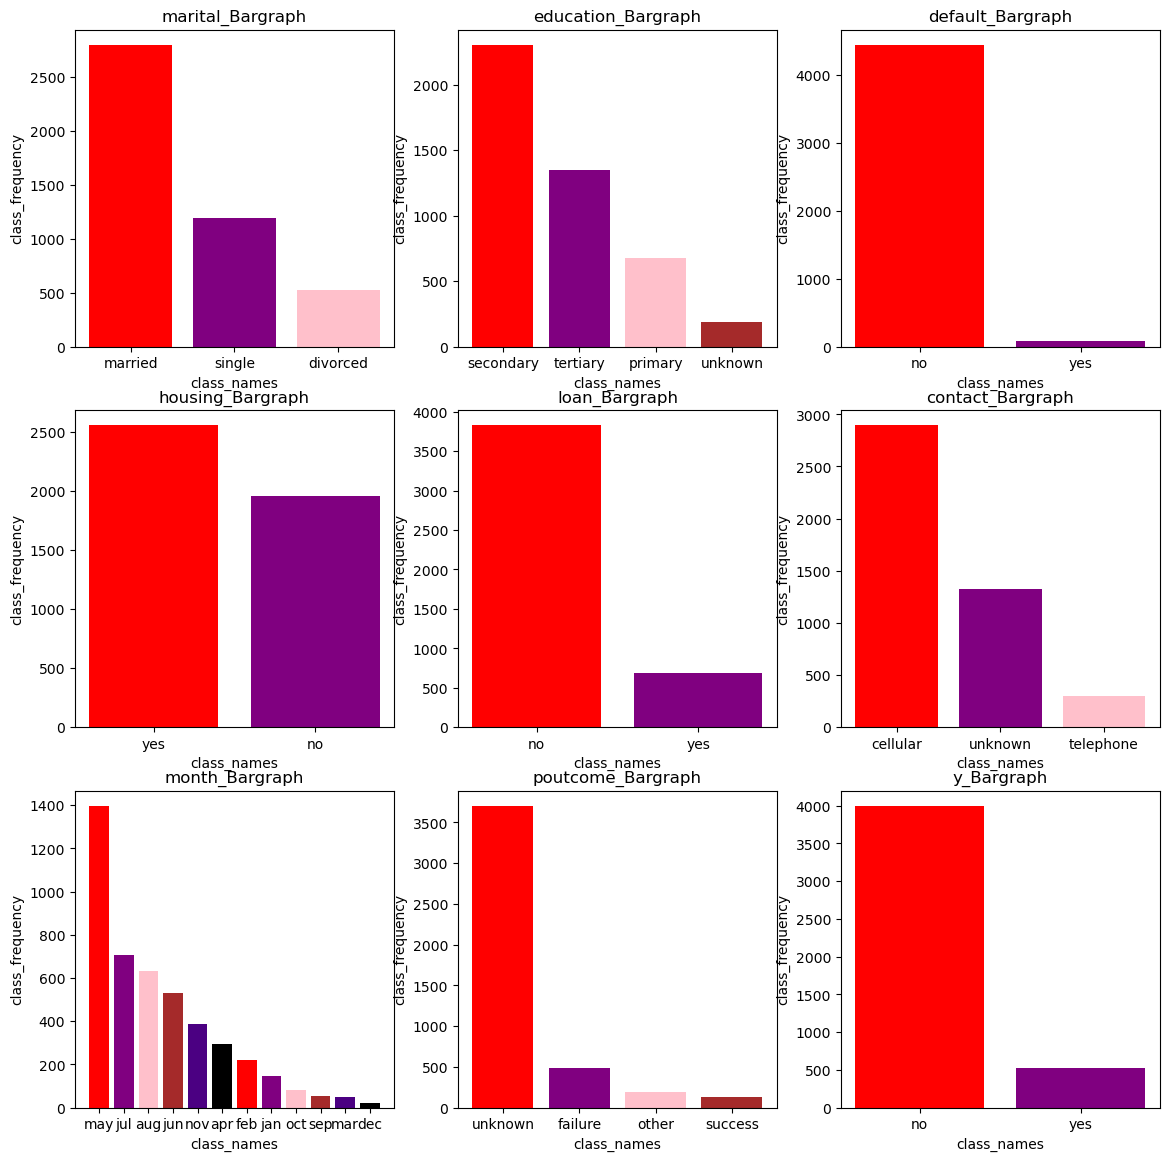

In [17]:
colors=['Red','Purple','Pink','Brown','Indigo','Black']
plt.figure(figsize=(14,14))
for i in range(1,len(cat)):
    keys=bank_fd[cat[i]].value_counts().keys()
    values=bank_fd[cat[i]].value_counts().values
    
    plt.subplot(3,3,i)
    plt.bar(keys,
            values,
            color=colors)
    plt.xlabel('class_names')
    plt.ylabel('class_frequency')
    plt.title(f'{cat[i]}_Bargraph')

In [20]:
keys = list(keys)
values = list(values)
keys,values

(['no', 'yes'], [4000, 521])

In [30]:
keys=bank_fd['job'].value_counts().keys()
values=bank_fd['job'].value_counts().values

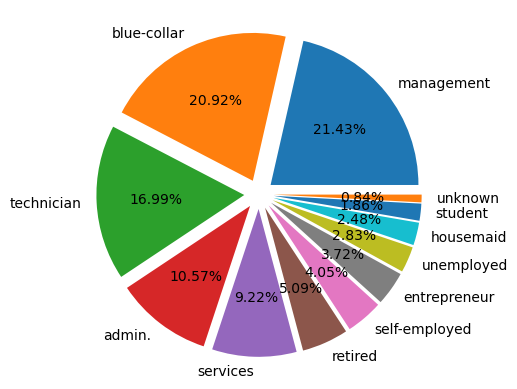

In [34]:
plt.pie(values,
        labels=keys,
        autopct='%0.2f%%',
        startangle=0,
        explode=[0.1 for i in range(12)],
        radius=1)
plt.show()

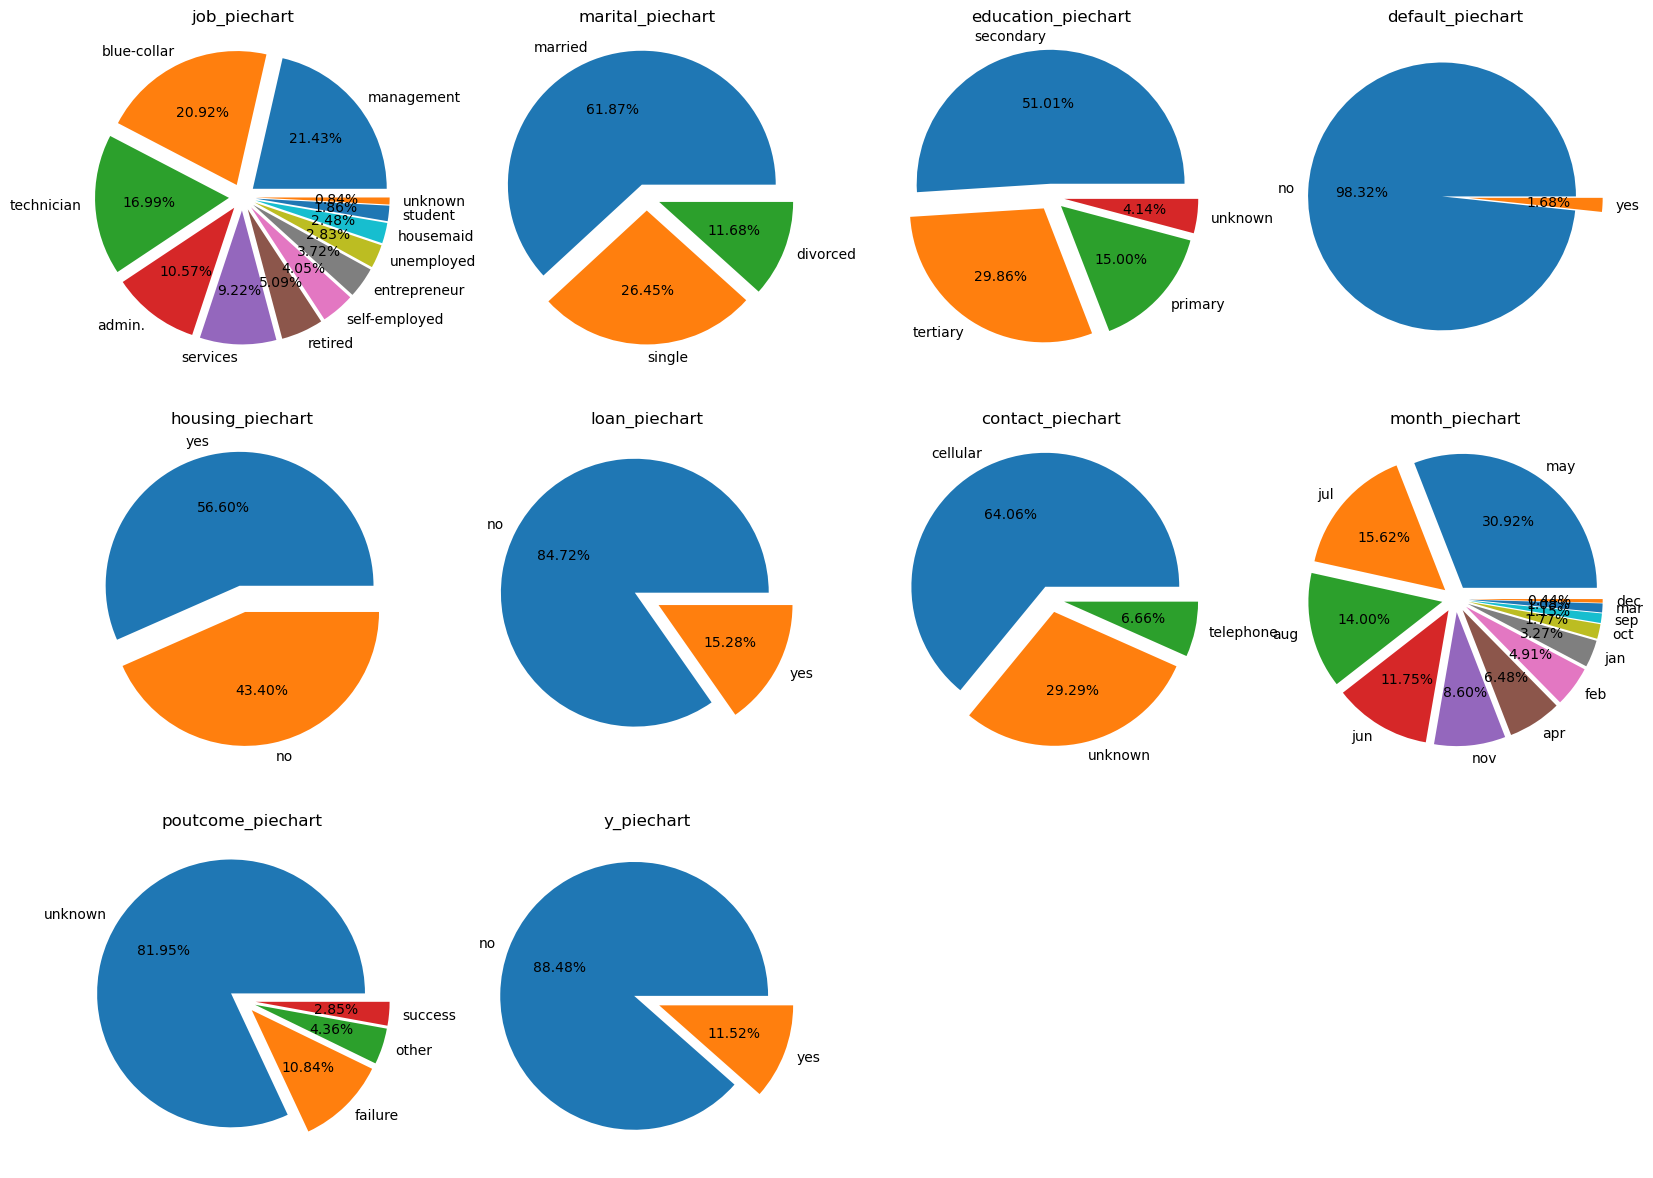

In [35]:
plt.figure(figsize=(20,20))
for i in range(len(cat)):
    keys=bank_fd[cat[i]].value_counts().keys()
    values=bank_fd[cat[i]].value_counts().values
    colors=['Red','Blue','Green','Purple','Cyan','Yellow','Orange','Blue','Pink','Brown','Silver','Black']
    plt.subplot(4,4,i+1)

    plt.pie(values,labels=keys,autopct='%0.2f%%',explode=[0.1 for i in range(len(keys))])
    plt.title(f'{cat[i]}_piechart')

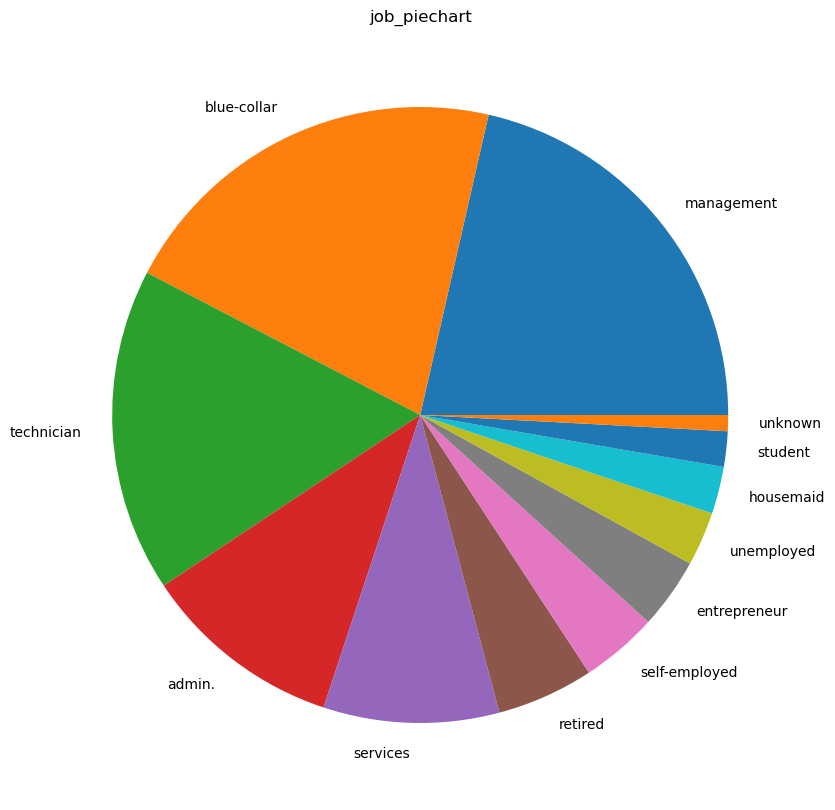

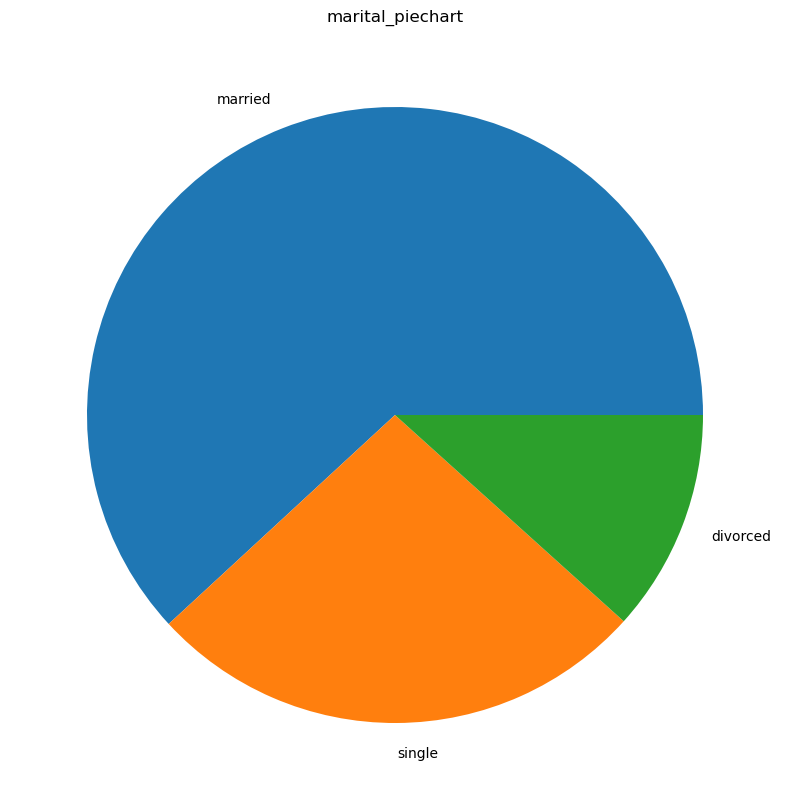

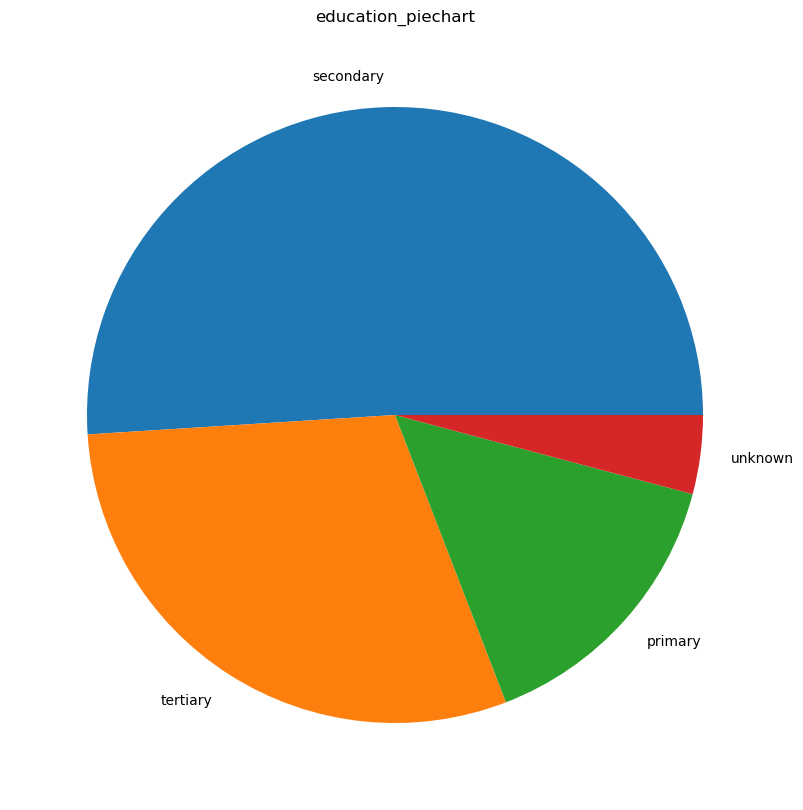

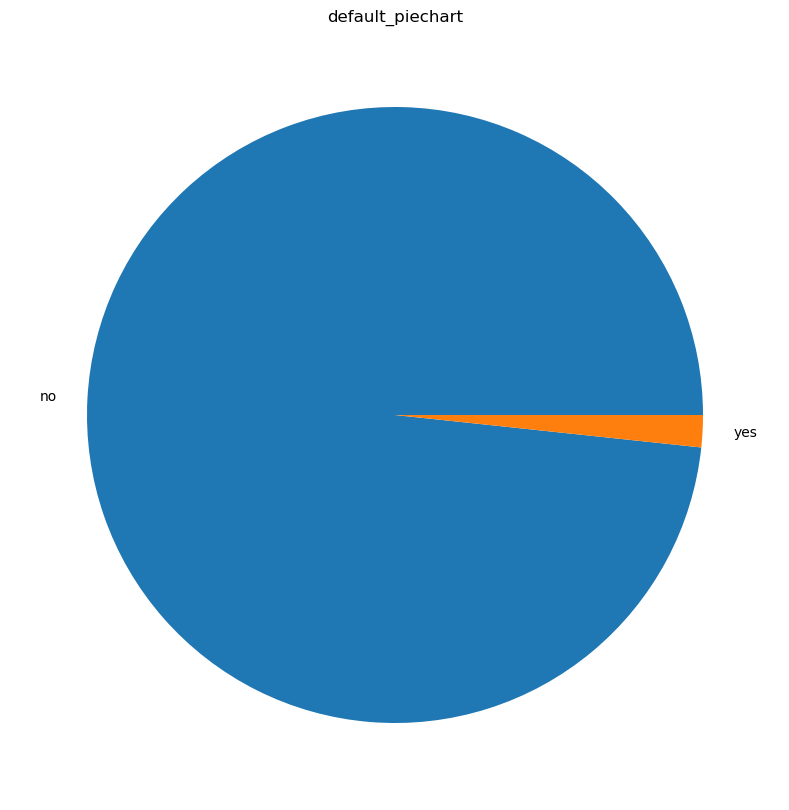

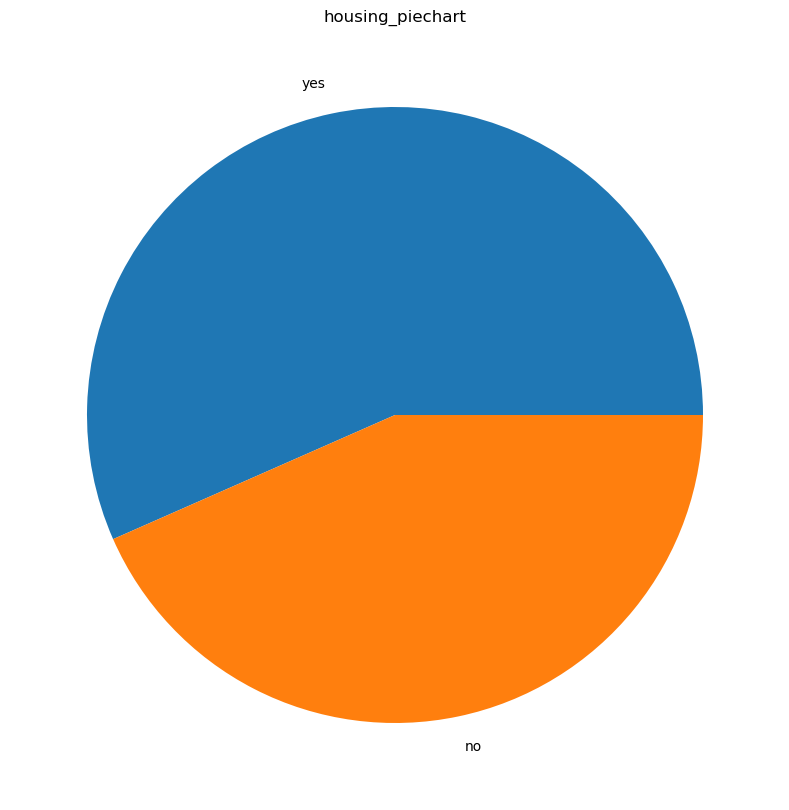

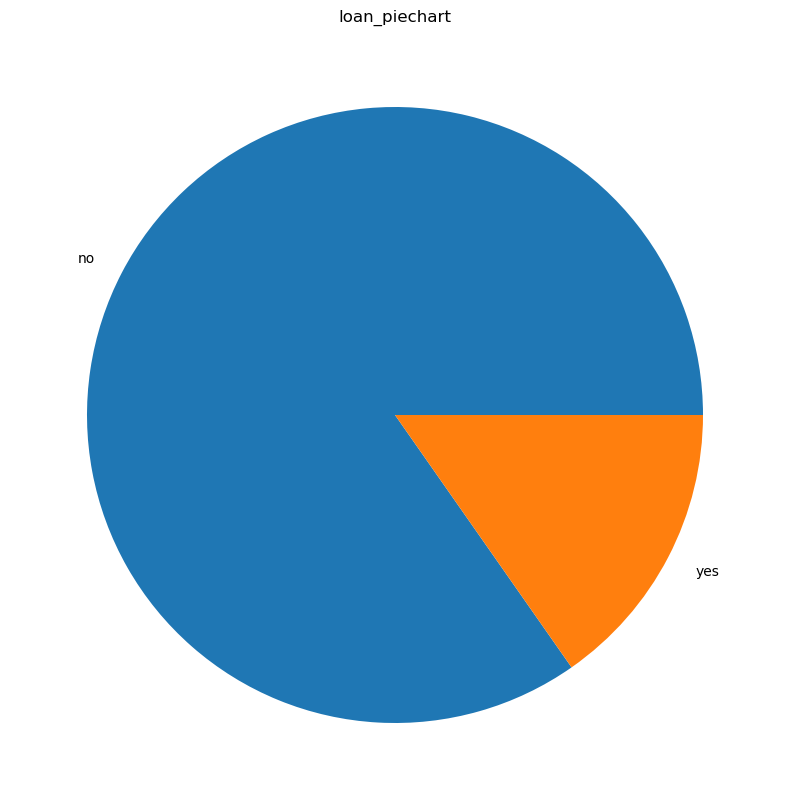

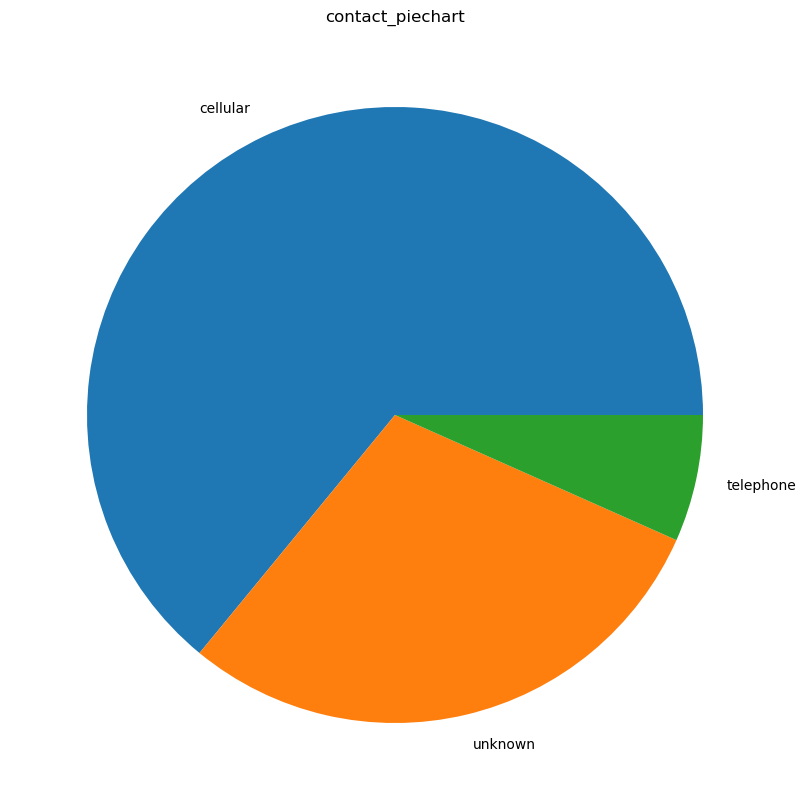

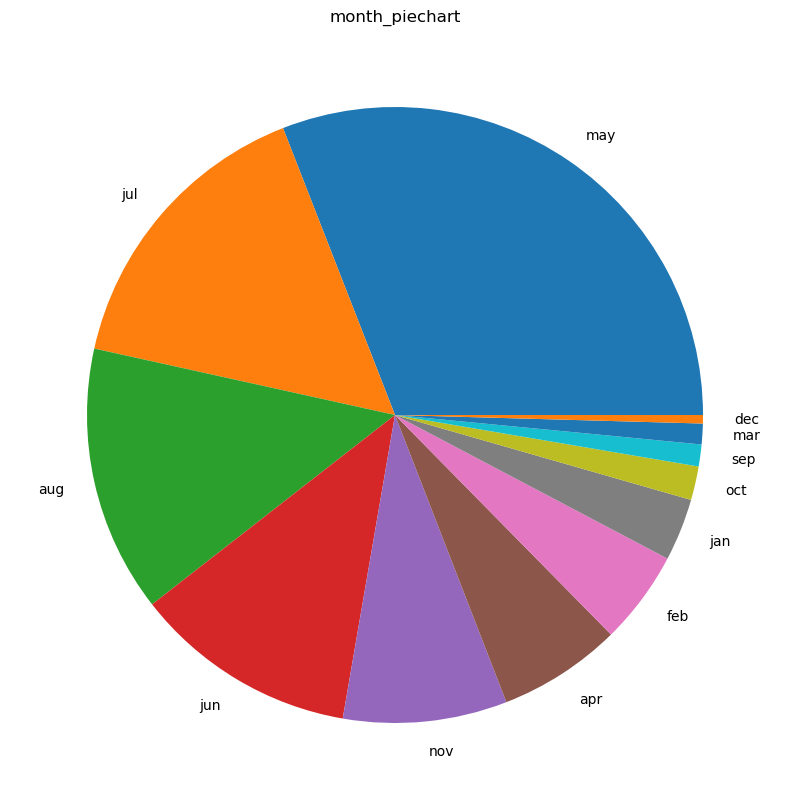

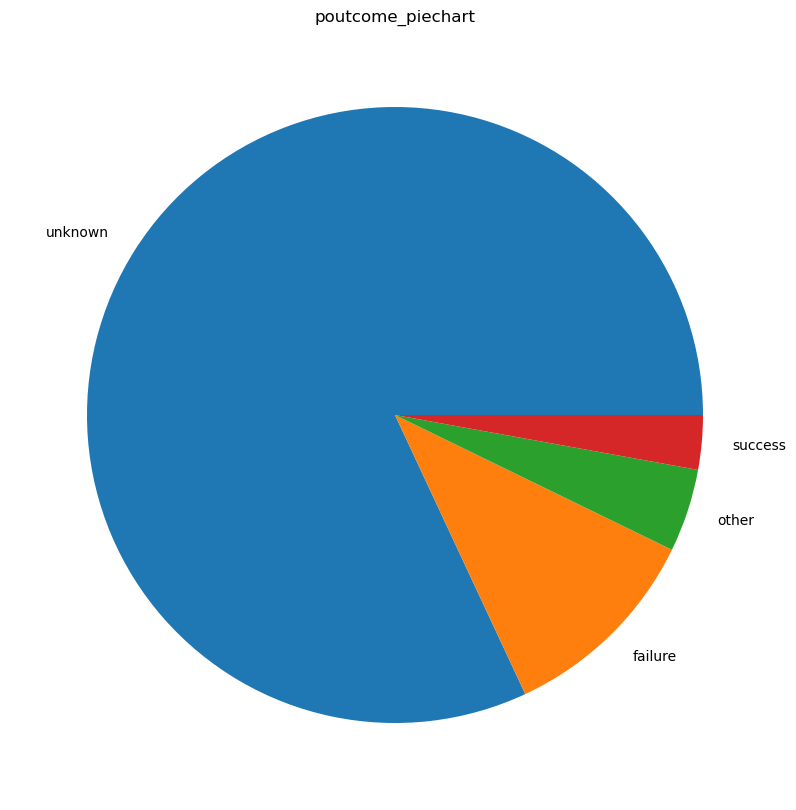

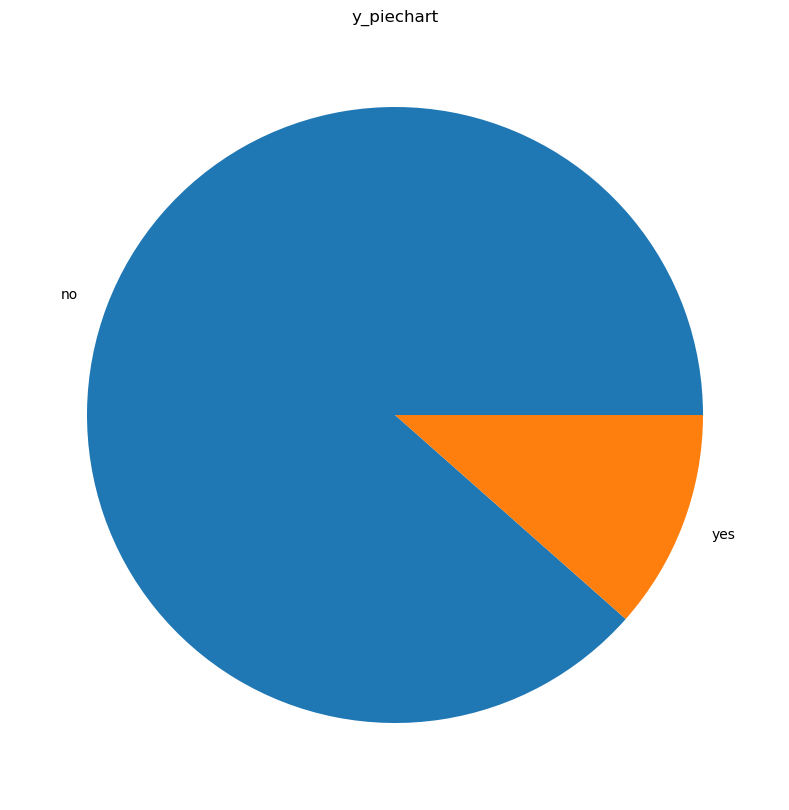

In [44]:

for i in cat:
    keys=bank_fd[i].value_counts().keys()
    values=bank_fd[i].value_counts().values
    colors=['Red','Blue','Green','Purple','Cyan','Yellow','Orange','Blue','Pink','Brown','Silver','Black']
    plt.figure(figsize=(15,10))
    plt.pie(values,labels=keys)
    plt.title(f'{i}_piechart')